## Section 2

In [2]:
%pip install rawpy

  Using cached rawpy-0.26.1-cp312-cp312-win_amd64.whl.metadata (9.8 kB)
Using cached rawpy-0.26.1-cp312-cp312-win_amd64.whl (884 kB)
Note: you may need to restart the kernel to use updated packages.


ISO800: N=60 frames | a=3.41, b=-6.89e+03 | patches=23375
ISO1600: N=60 frames | a=6.89, b=-1.38e+04 | patches=23375
ISO3200: N=60 frames | a=13.8, b=-2.72e+04 | patches=23375


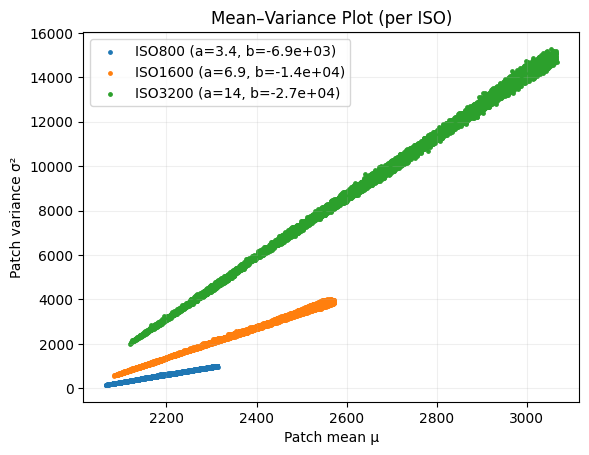

In [3]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import rawpy


def load_stack(folder):
    paths = sorted(glob.glob(os.path.join(folder, "*.CR3"))) + \
            sorted(glob.glob(os.path.join(folder, "*.cr3")))
    if not paths:
        raise FileNotFoundError(f"No CR3 in {folder}")

    imgs = []
    for p in paths:
        try:
            with rawpy.imread(p) as raw:
                imgs.append(raw.raw_image_visible.astype(np.float32))
        except Exception as e:
            print("Skip:", os.path.basename(p), "|", type(e).__name__)

    if len(imgs) < 2:
        raise RuntimeError(f"{os.path.basename(folder)}: only {len(imgs)} readable files (need >= 2).")

    return np.stack(imgs, 0)  # shape: (N, H, W)


# -------------------------------------------------
# TODO: Implement patch statistics
# -------------------------------------------------
def patch_stats(img, p=32):
    """
    Compute the mean value of non-overlapping p×p patches.

    Input
    -----
    img : 2D image (H, W)
    p   : patch size

    Output
    ------
    patch_means : 1D array of shape (num_patches,)
    """

    # 1. Get image height and width
    H, W = img.shape

    # 2. Crop the image so that both dimensions are divisible by p
    #    (Hint: use integer division with //)
    H2 , W2 = (H // p) * p, (W // p) * p

    # 3. Extract the valid region
    img_crop = img[:H2, :W2]

    # 4. Reshape the image into patches
    #    Desired structure: (#patch_H, p, #patch_W, p)
    patches = img_crop.reshape(H2 // p, p, W2 // p, p)

    # 5. Compute the mean of each patch
    #    (Hint: average across the patch dimensions)
    patch_means = patches.mean(axis=(1, 3))

    # 6. Flatten to a 1D vector
    patch_means = patch_means.flatten()

    return patch_means


def fit_line(x, y):
    a, b = np.linalg.lstsq(np.c_[x, np.ones_like(x)], y, rcond=None)[0]
    return float(a), float(b)


def analyze_iso_folder(folder, p=32):
    S = load_stack(folder)
    tag = os.path.basename(folder)

    mean_img = S.mean(0)
    var_img  = S.var(0, ddof=1)

    mu = patch_stats(mean_img, p=p)
    s2 = patch_stats(var_img,  p=p)

    mask = np.isfinite(mu) & np.isfinite(s2)
    mu, s2 = mu[mask], s2[mask]

    a, b = fit_line(mu, s2)

    print(f"{tag}: N={S.shape[0]} frames | a={a:.3g}, b={b:.3g} | patches={mu.size}")
    return mu, s2, a, b


def run_all(base_dir, iso_dirs=("ISO800","ISO1600","ISO3200"), p=32):
    plt.figure()

    for d in iso_dirs:
        folder = os.path.join(base_dir, d)
        mu, s2, a, b = analyze_iso_folder(folder, p=p)

        plt.scatter(mu, s2, s=6, label=f"{d} (a={a:.2g}, b={b:.2g})")
        xs = np.array([mu.min(), mu.max()])
        plt.plot(xs, a*xs + b)

    plt.xlabel("Patch mean μ")
    plt.ylabel("Patch variance σ²")
    plt.title("Mean–Variance Plot (per ISO)")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()


if __name__ == "__main__":
    run_all("ISO",
            iso_dirs=("ISO800","ISO1600","ISO3200"), # Name of each ISO folder (edit as needed)
            p=32)

## Section 3

In [5]:
%pip install opencv-python

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)
Note: you may need to restart the kernel to use updated packages.


In [6]:
import numpy as np 
import matplotlib.pyplot as plt 
import cv2

In [7]:
def add_poisson_noise(image, Nmax):
    scaled_image = image * Nmax
    noisy_image = np.random.poisson(scaled_image)
    return noisy_image / Nmax

def add_gaussian_noise(image, sigma):
    noise = np.random.normal(0, sigma, image.shape)
    return image + noise

In [8]:
image1 = (cv2.imread("dybantsa.png", cv2.IMREAD_GRAYSCALE).astype(np.float64)) / 255.0

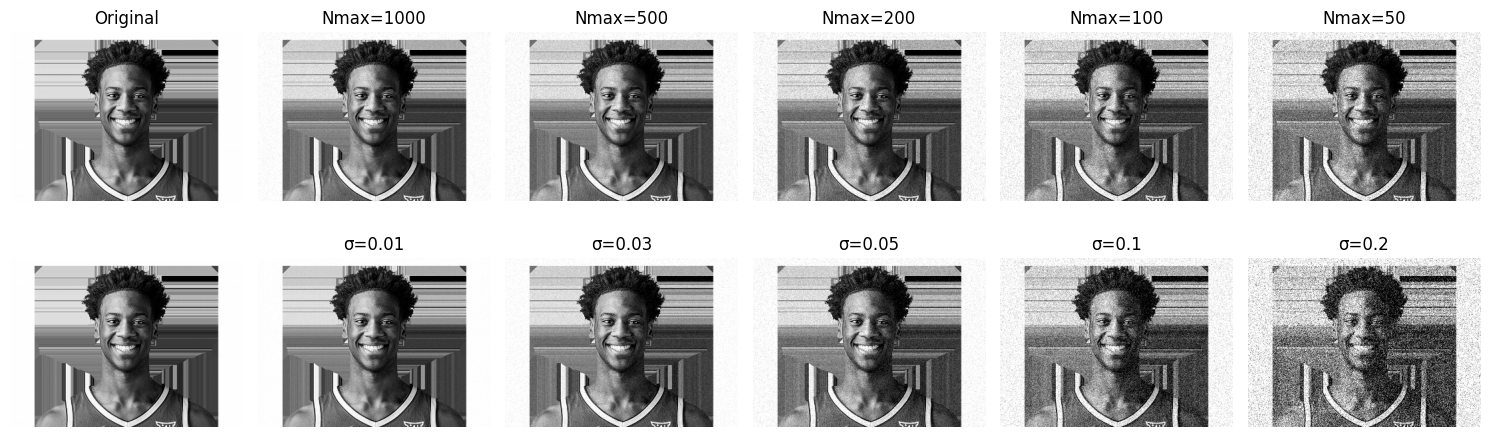

In [11]:
def visualize_noise(img):

    # Increasing noise levels
    Nmax_vals = [1000, 500, 200, 100, 50]
    sigma_vals = [0.01, 0.03, 0.05, 0.1, 0.2]

    _, axes = plt.subplots(2, 6, figsize=(15,5))

    # Original image
    axes[0,0].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[0,0].set_title("Original")
    axes[0,0].axis("off")

    axes[1,0].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[1,0].axis("off")

    for i, Nmax in enumerate(Nmax_vals):
        noisy = add_poisson_noise(img, Nmax)
        axes[0,i+1].imshow(noisy, cmap='gray', vmin=0, vmax=1)
        axes[0,i+1].set_title(f"Nmax={Nmax}")
        axes[0,i+1].axis("off")

    for i, sigma in enumerate(sigma_vals):
        noisy = add_gaussian_noise(img, sigma)
        axes[1,i+1].imshow(noisy, cmap='gray', vmin=0, vmax=1)
        axes[1,i+1].set_title(f"σ={sigma}")
        axes[1,i+1].axis("off")

    axes[0,0].set_ylabel("Poisson")
    axes[1,0].set_ylabel("Gaussian")

    plt.tight_layout()
    plt.show()

visualize_noise(image1)

In [10]:
def sensor_model(img, NMax, g, sigma):
    img_poisson = add_poisson_noise(img, NMax)
    signal = g * img_poisson
    img_gaussian = add_gaussian_noise(signal, sigma)
    return np.clip(img_gaussian, 0, 1)


## Sec 5

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def make_test_image(H=256, W=256):
    y = np.linspace(0, 1, H)[:, None]
    x = np.linspace(0, 1, W)[None, :]
    img = 0.15 + 0.7 * (0.6*x + 0.4*y)

    img[40:90, 40:90]     = 0.95
    img[140:200, 150:220] = 0.85
    img[180:240, 10:90]   = 0.05

    return np.clip(img, 0, 1)


# -------------------------------------------------
# TODO 1: Sensor noise model
# -------------------------------------------------
def sensor(img01, Nmax=20, QE=1.0, gain=1.0,
           read_sigma_e=2.0, adc_sigma_dn=0.5,
           bit_depth=12, rng=None):
    """
    Simulate a simple camera sensor model.

    Steps:
    1. Apply photon (Poisson) noise
    2. Add read noise (Gaussian)
    3. Add ADC noise
    4. Clip values based on bit depth
    """

    rng = np.random.default_rng() if rng is None else rng
    img01 = np.clip(img01, 0, 1)

    # Photon noise
    L = ...

    # Read noise (electrons)
    I = ...

    # ADC noise
    I += ...

    # Clip to sensor range
    I = ...

    return ...


# -------------------------------------------------
# Run comparison between two cameras
# -------------------------------------------------
rng = np.random.default_rng(0)

X = make_test_image()

Nmax = 20

camA = dict(QE=0.5, read_sigma_e=6.0, adc_sigma_dn=1.2, bit_depth=10)
camB = dict(QE=1.0, read_sigma_e=1.5, adc_sigma_dn=0.5, bit_depth=14)

YA = sensor(X, Nmax=Nmax, rng=rng, **camA)
YB = sensor(X, Nmax=Nmax, rng=rng, **camB)


# -------------------------------------------------
# Display results
# -------------------------------------------------
def show(img, title):
    plt.figure()
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.colorbar()
    plt.show()


show(YA, "Camera A (cheap)")
show(YB, "Camera B (expensive)")


# -------------------------------------------------
# TODO 2: Compute a simple SNR-like metric
# -------------------------------------------------
def snr_like(Y, mask):
    """
    Compute a simple signal-to-noise estimate:
        mean / std
    within a selected region.
    """

    vals = ...

    return ...


# Define regions of interest
dark = X < 0.12
mid  = (X > 0.35) & (X < 0.55)

print("Dark region SNR:")
print("Camera A:", snr_like(YA, dark))
print("Camera B:", snr_like(YB, dark))

print("\nMid-tone region SNR:")
print("Camera A:", snr_like(YA, mid))
print("Camera B:", snr_like(YB, mid))